In [1]:
import model1_free_text_chunked_pipeline_v3 as m1fc3

In [2]:
train_df, test_df = m1fc3.prepare_train_test_data(
    "free-text.csv",
    "synthetic_free_text.csv",
    chunk_size=50,
    test_size=0.2,
    random_state=42
)

Real raw shape: (562583, 9)
Synthetic raw shape: (562372, 9)

Real train chunks shape: (8889, 19)
Real test chunks shape: (2264, 19)
Synthetic train chunks shape: (8886, 19)
Synthetic test chunks shape: (2263, 19)

Final train shape: (17775, 19)
Final test shape: (4527, 19)

Train class counts:
label
0    8889
1    8886
Name: count, dtype: int64

Test class counts:
label
0    2264
1    2263
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = m1fc3.preprocess_train_test(train_df, test_df)


Dropping columns: ['participant', 'session', 'chunk_id']

X_train shape: (17775, 15)
X_test shape: (4527, 15)


In [4]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())
print(X_train.columns)

(17775, 15) (4527, 15)
label
0    8889
1    8886
Name: count, dtype: int64
label
0    2264
1    2263
Name: count, dtype: int64
Index(['DU_hold_mean', 'DU_hold_std', 'DD_mean', 'DD_std', 'DU_flight_mean',
       'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std',
       'total_events', 'total_time', 'avg_time_per_event', 'overall_mean',
       'overall_std'],
      dtype='object')


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m1fc3.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m1fc3.scale_data(X_train_mi, X_test_mi)
mi_results = m1fc3.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
               Feature     Score
0         DU_hold_mean  0.180736
1          DU_hold_std  0.175204
8              UU_mean  0.133360
3               DD_std  0.111530
9               UU_std  0.101824
7               UD_std  0.096520
14         overall_std  0.095002
4       DU_flight_mean  0.093668
12  avg_time_per_event  0.093332
11          total_time  0.092336

Model: Logistic Regression
Accuracy: 0.588469184890656

Confusion Matrix:
[[1389  875]
 [ 988 1275]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.61      0.60      2264
           1       0.59      0.56      0.58      2263

    accuracy                           0.59      4527
   macro avg       0.59      0.59      0.59      4527
weighted avg       0.59      0.59      0.59      4527

ROC-AUC: 0.6704619091265387

Model: Linear SVM
Accuracy: 0.5924453280318092

Confusion Matrix:
[[1458  806]
 [1039 1224]]

Classification Report:
    

In [6]:
X_train_anova, X_test_anova, anova_features, anova_scores = m1fc3.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m1fc3.scale_data(X_train_anova, X_test_anova)
anova_results = m1fc3.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Top ANOVA Features:
               Feature      Score       P_Value
7               UD_std  41.894505  9.885220e-11
14         overall_std  32.412489  1.266504e-08
0         DU_hold_mean  31.953421  1.603377e-08
6              UD_mean  30.887481  2.773573e-08
2              DD_mean  16.014180  6.312476e-05
11          total_time  16.014180  6.312476e-05
12  avg_time_per_event  16.014180  6.312476e-05
4       DU_flight_mean   9.948198  1.612750e-03
3               DD_std   5.025870  2.498366e-02
1          DU_hold_std   4.632591  3.138358e-02

Model: Logistic Regression
Accuracy: 0.5635078418378617

Confusion Matrix:
[[1383  881]
 [1095 1168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.61      0.58      2264
           1       0.57      0.52      0.54      2263

    accuracy                           0.56      4527
   macro avg       0.56      0.56      0.56      4527
weighted avg       0.56      0.56      0.56      452

In [7]:
X_train_corr, X_test_corr, corr_features, corr_scores = m1fc3.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m1fc3.scale_data(X_train_corr, X_test_corr)
corr_results = m1fc3.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
              Feature     Score
0              UD_std  0.048494
1         overall_std  0.042666
2        DU_hold_mean  0.042363
3             UD_mean  0.041652
4          total_time  0.030004
5             DD_mean  0.030004
6  avg_time_per_event  0.030004
7      DU_flight_mean  0.023652
8              DD_std  0.016814
9         DU_hold_std  0.016143

Model: Logistic Regression
Accuracy: 0.5635078418378617

Confusion Matrix:
[[1383  881]
 [1095 1168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.61      0.58      2264
           1       0.57      0.52      0.54      2263

    accuracy                           0.56      4527
   macro avg       0.56      0.56      0.56      4527
weighted avg       0.56      0.56      0.56      4527

ROC-AUC: 0.6480154318433425

Model: Linear SVM
Accuracy: 0.5710183344378176

Confusion Matrix:
[[1440  824]
 [1118 1145]]

Classification Report:
              precisi

In [8]:
X_train_var, X_test_var, var_features, var_scores = m1fc3.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m1fc3.scale_data(X_train_var, X_test_var)
var_results = m1fc3.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
          Feature      Score
0      total_time  80.682807
1          DD_std   3.392809
2   DU_flight_std   2.044626
3          UD_std   1.722937
4     DU_hold_std   1.482590
5  DU_flight_mean   0.064743
6          UU_std   0.050547
7         UD_mean   0.048018
8    DU_hold_mean   0.043711
9         DD_mean   0.032273

Model: Logistic Regression
Accuracy: 0.5723437154848686

Confusion Matrix:
[[1234 1030]
 [ 906 1357]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.55      0.56      2264
           1       0.57      0.60      0.58      2263

    accuracy                           0.57      4527
   macro avg       0.57      0.57      0.57      4527
weighted avg       0.57      0.57      0.57      4527

ROC-AUC: 0.626977190289634

Model: Linear SVM
Accuracy: 0.5791915175612988

Confusion Matrix:
[[1260 1004]
 [ 901 1362]]

Classification Report:
              precision    recall  f1-score   support

   

In [9]:
X_train_md, X_test_md, md_features, md_scores = m1fc3.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m1fc3.scale_data(X_train_md, X_test_md)
md_results = m1fc3.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
          Feature     Score
0      total_time  0.538995
1          UD_std  0.127303
2          DD_std  0.061939
3     DU_hold_std  0.039310
4   DU_flight_std  0.026077
5         UD_mean  0.018254
6    DU_hold_mean  0.017713
7     overall_std  0.014115
8  DU_flight_mean  0.012036
9         DD_mean  0.010780

Model: Logistic Regression
Accuracy: 0.5714601281201679

Confusion Matrix:
[[1405  859]
 [1081 1182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.62      0.59      2264
           1       0.58      0.52      0.55      2263

    accuracy                           0.57      4527
   macro avg       0.57      0.57      0.57      4527
weighted avg       0.57      0.57      0.57      4527

ROC-AUC: 0.6479830316865726

Model: Linear SVM
Accuracy: 0.5776452396730727

Confusion Matrix:
[[1463  801]
 [1111 1152]]

Classification Report:
              precision    recall  f1-score   support

      

In [10]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m1fc3.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m1fc3.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m1fc3.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)


RFE Logistic Regression Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.5668212944554892

Confusion Matrix:
[[1363  901]
 [1060 1203]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.60      0.58      2264
           1       0.57      0.53      0.55      2263

    accuracy                           0.57      4527
   macro avg       0.57      0.57      0.57      4527
weighted avg       0.57      0.57      0.57      4527

ROC-AUC: 0.6635171502227413

Model: Linear SVM
Accuracy: 0.5800751049259996

Confusion Matrix:
[[1439  825]
 [1076 1187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60      2264
           1       0.59      0.52      0.56      2263

    accuracy                           0.58      4527
   macro avg  

In [11]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m1fc3.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m1fc3.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m1fc3.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.5668212944554892

Confusion Matrix:
[[1363  901]
 [1060 1203]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.60      0.58      2264
           1       0.57      0.53      0.55      2263

    accuracy                           0.57      4527
   macro avg       0.57      0.57      0.57      4527
weighted avg       0.57      0.57      0.57      4527

ROC-AUC: 0.6635171502227413

Model: Linear SVM
Accuracy: 0.5800751049259996

Confusion Matrix:
[[1439  825]
 [1076 1187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60      2264
           1       0.59      0.52      0.56      2263

    accuracy                           0.58      4527
   macro avg       0.58

In [12]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m1fc3.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m1fc3.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m1fc3.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'total_time', 'overall_std']

Model: Logistic Regression
Accuracy: 0.5674839849790148

Confusion Matrix:
[[1363  901]
 [1057 1206]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.60      0.58      2264
           1       0.57      0.53      0.55      2263

    accuracy                           0.57      4527
   macro avg       0.57      0.57      0.57      4527
weighted avg       0.57      0.57      0.57      4527

ROC-AUC: 0.6630990710914091

Model: Linear SVM
Accuracy: 0.5785288270377733

Confusion Matrix:
[[1438  826]
 [1082 1181]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60      2264
           1       0.59      0.52      0.55      2263

    accuracy                           0.58      4527
   macro avg       0.5

In [13]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m1fc3.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m1fc3.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m1fc3.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)


SelectFromModel Logistic Regression Features:
           Feature      Score
14     overall_std  26.595415
0     DU_hold_mean  16.974534
4   DU_flight_mean   6.391794
8          UU_mean   3.972206
13    overall_mean   2.558786
1      DU_hold_std   2.484233
9           UU_std   1.567692
6          UD_mean   1.289361
7           UD_std   0.947932
3           DD_std   0.469373

Model: Logistic Regression
Accuracy: 0.5668212944554892

Confusion Matrix:
[[1363  901]
 [1060 1203]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.60      0.58      2264
           1       0.57      0.53      0.55      2263

    accuracy                           0.57      4527
   macro avg       0.57      0.57      0.57      4527
weighted avg       0.57      0.57      0.57      4527

ROC-AUC: 0.6635171502227413

Model: Linear SVM
Accuracy: 0.5800751049259996

Confusion Matrix:
[[1439  825]
 [1076 1187]]

Classification Report:
              precision

In [14]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m1fc3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m1fc3.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m1fc3.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)


SelectFromModel Random Forest Features:
          Feature     Score
1     DU_hold_std  0.192283
0    DU_hold_mean  0.159299
8         UU_mean  0.113219
3          DD_std  0.074125
7          UD_std  0.059551
9          UU_std  0.057819
5   DU_flight_std  0.055350
14    overall_std  0.053658
6         UD_mean  0.052608
11     total_time  0.045779

Model: Logistic Regression
Accuracy: 0.593549812237685

Confusion Matrix:
[[1436  828]
 [1012 1251]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.63      0.61      2264
           1       0.60      0.55      0.58      2263

    accuracy                           0.59      4527
   macro avg       0.59      0.59      0.59      4527
weighted avg       0.59      0.59      0.59      4527

ROC-AUC: 0.6639385474424175

Model: Linear SVM
Accuracy: 0.602606582725867

Confusion Matrix:
[[1511  753]
 [1046 1217]]

Classification Report:
              precision    recall  f1-score   support

In [15]:
summary_df = m1fc3.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)

summary_df.head(15)


Feature Selection Summary:
               Feature  Times_Selected
0         DU_hold_mean              10
1          DU_hold_std              10
3               DD_std              10
5               UD_std              10
6          overall_std               9
7       DU_flight_mean               9
10             UD_mean               9
4               UU_std               7
9           total_time               7
2              UU_mean               6
11             DD_mean               4
8   avg_time_per_event               3
12       DU_flight_std               3
13        overall_mean               3


,Feature,Times_Selected
0,DU_hold_mean,10
1,DU_hold_std,10
3,DD_std,10
5,UD_std,10
6,overall_std,9
7,DU_flight_mean,9
10,UD_mean,9
4,UU_std,7
9,total_time,7
2,UU_mean,6


In [16]:
best_model = dt_model = m1fc3.get_models()["Decision Tree"]

# Use one strong feature set (RFE RF is good)
X_train_best, X_test_best, _ = m1fc3.select_rfe_rf(
    X_train, y_train, X_test, k=10
)

X_train_best_scaled, X_test_best_scaled = m1fc3.scale_data(
    X_train_best, X_test_best
)

best_model.fit(X_train_best_scaled, y_train)

y_pred_best = best_model.predict(X_test_best_scaled)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Best Model: Decision Tree")
print("Accuracy:", (y_pred_best == y_test).mean())
print("Confusion Matrix:\n", cm)


RFE Random Forest Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'total_time', 'overall_std']
Best Model: Decision Tree
Accuracy: 0.8701126573889993
Confusion Matrix:
 [[1802  462]
 [ 126 2137]]


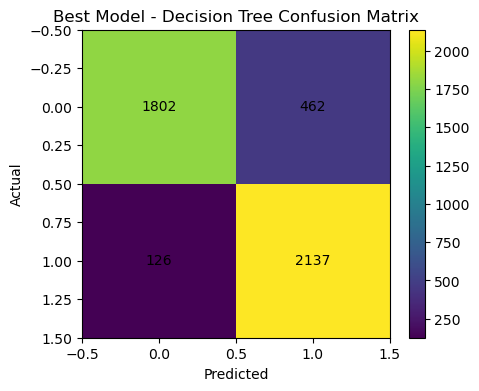

In [17]:
m1fc3.plot_confusion_matrix(cm, title="Best Model - Decision Tree Confusion Matrix")

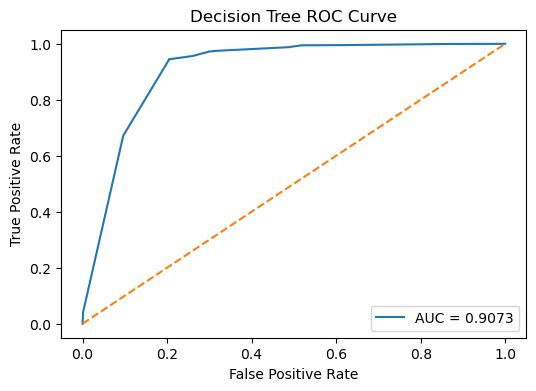

In [18]:
m1fc3.plot_roc(
    best_model,
    X_test_best_scaled,
    y_test,
    title="Decision Tree ROC Curve"
)


Feature: DU_hold_std
Real Mean: 0.6369236249586361
Synthetic Mean: 0.43621314377784415
Real Std: 2.8272348101832767
Synthetic Std: 0.951682779471724


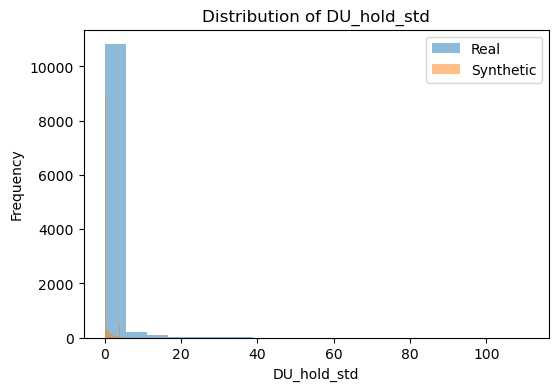


Feature: UD_std
Real Mean: 1.0620040573349911
Synthetic Mean: 0.6174118775785379
Real Std: 5.370527702624822
Synthetic Std: 0.881551982500001


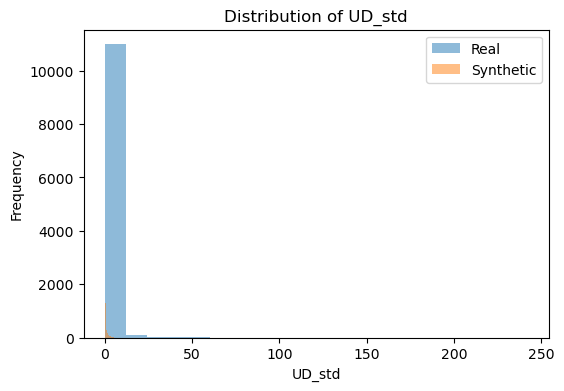

In [19]:
m1fc3.plot_feature_distribution_from_train_test(
    train_df,
    test_df,
    "DU_hold_std"
)

m1fc3.plot_feature_distribution_from_train_test(
    train_df,
    test_df,
    "UD_std"
)